In [2]:
import numpy as np
import sklearn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [80]:
# import data
df = pd.read_csv('~/python/data/ml_zoomcamp/course_lead_scoring_2026.csv')
df.head()

,lead_source,industry,employment_status,location,annual_income,number_of_courses_viewed,interaction_count,lead_score,converted
0,organic_search,technology,employed,europe,88160.0,3,4,0.64,1
1,social_media,technology,employed,south_america,72688.0,3,7,0.72,1
2,referral,retail,employed,europe,44697.0,3,4,0.58,1
3,paid_ads,manufacturing,student,NaN,NaN,3,6,0.57,0
4,referral,manufacturing,student,north_america,24062.0,4,5,0.62,1


### Data Preparation

Check if the missing values are presented in the features

If there are missing values:

    1. For categorical features, replace them with 'NA'
    2. For numerical features replace them with 0.0

In [39]:
# Check the null values are in the columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               4852 non-null   str    
 1   industry                  4760 non-null   str    
 2   employment_status         4806 non-null   str    
 3   location                  4792 non-null   str    
 4   annual_income             4631 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                4965 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 351.7 KB


In [81]:
# Split numeric and categorical data
numeric = [col for col in df.columns if df[col].dtype != 'str']
numeric.remove('converted') # remove target
categorical = [col for col in df.columns if df[col].dtype == 'str']
print(numeric)
print(categorical)

['annual_income', 'number_of_courses_viewed', 'interaction_count', 'lead_score']
['lead_source', 'industry', 'employment_status', 'location']


In [82]:
# Fill na
df[numeric] = df[numeric].fillna(0.0)
df[categorical] = df[categorical].fillna('NA')
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   lead_source               5000 non-null   str    
 1   industry                  5000 non-null   str    
 2   employment_status         5000 non-null   str    
 3   location                  5000 non-null   str    
 4   annual_income             5000 non-null   float64
 5   number_of_courses_viewed  5000 non-null   int64  
 6   interaction_count         5000 non-null   int64  
 7   lead_score                5000 non-null   float64
 8   converted                 5000 non-null   int64  
dtypes: float64(2), int64(3), str(4)
memory usage: 351.7 KB


### Question 1

What is the mode of 'industry'?

In [42]:
# Just use value counts
df['industry'].value_counts()

industry
technology       1173
retail            925
healthcare        840
finance           720
education         639
manufacturing     463
NA                240
Name: count, dtype: int64

### Question 2

Which two numeric features are the most correlated with eachother?

<Axes: >

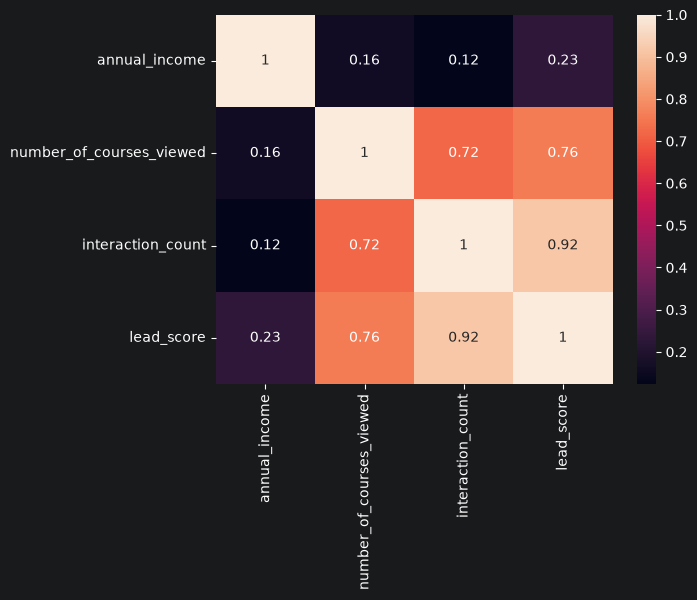

In [43]:
# Use correlation matrix
corr_mat = df[numeric].corr()

sns.heatmap(data=corr_mat, annot=True)

In [83]:
df_full_train, df_test = sklearn.model_selection.train_test_split(df, test_size=0.2, random_state=42)
df_train, df_val = sklearn.model_selection.train_test_split(
    df_full_train, test_size=0.25, random_state=42
)
print(df_train.shape, df_val.shape, df_test.shape)

(3000, 9) (1000, 9) (1000, 9)


### Question 3

Calculate the mutual information score between the categorical variables and the target

Use the training set only and round the answers to 2 decimal places - which feature has the biggest information score?

          categories  mutualInfoScore
0        lead_source         0.034346
1           industry         0.001995
2  employment_status         0.018966
3           location         0.001043


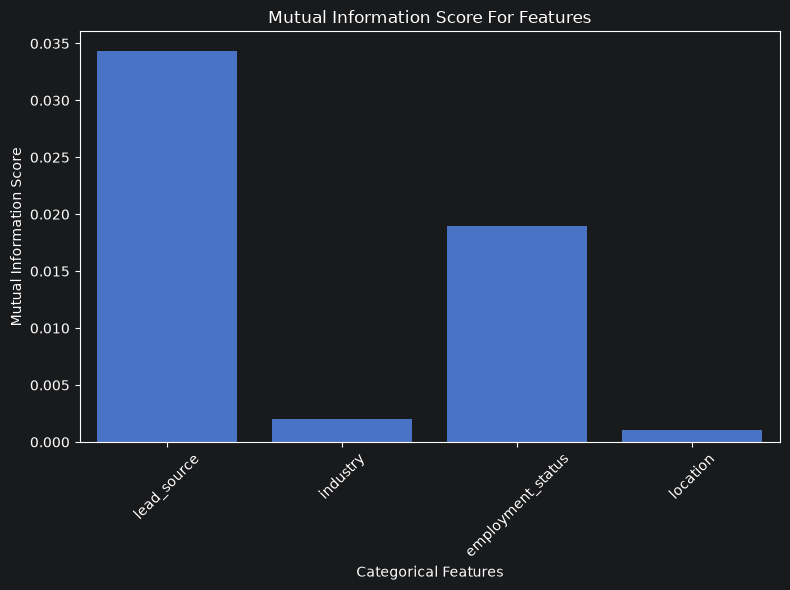

In [45]:
# Get a dataframe of the categorical variables
cat_df = pd.DataFrame(
    data=None
)
cat_df['categories'] = categorical

# Want to add a column with the mutual information
# Use a lambda function to apply the mutual information score to each feature row-wise
cat_df['mutualInfoScore'] = cat_df['categories'].apply(lambda x: sklearn.metrics.mutual_info_score(df_train[x], df_train['converted']))
print(cat_df)
# Visualise results
fig, ax = plt.subplots(nrows=1, ncols=1, figsize=(8, 6))
sns.barplot(
    data=cat_df,
    x='categories',
    y='mutualInfoScore',
    ax=ax
)

ax.tick_params('x', labelrotation=45)
ax.set_title('Mutual Information Score For Features')
ax.set_xlabel('Categorical Features')
ax.set_ylabel('Mutual Information Score')
plt.tight_layout()

### Question 4

Train the model with logistic regression and calculate the accuracy on the validation set

In [85]:
# First encode the categorical variables
# We can turn categorical columns into binary numeric columns using one-hot-encoding
encoder = sklearn.preprocessing.OneHotEncoder(sparse_output=False)

encoded_data = encoder.fit_transform(df[categorical])

encoded_df = pd.DataFrame(
    encoded_data,
    columns=encoder.get_feature_names_out(categorical)
)

new_df = pd.concat(
    [df[numeric], encoded_df, df['converted']],
    axis=1
)
new_df

,annual_income,number_of_courses_viewed,interaction_count,lead_score,lead_source_NA,lead_source_events,lead_source_organic_search,lead_source_paid_ads,lead_source_referral,lead_source_social_media,...,employment_status_self_employed,employment_status_student,employment_status_unemployed,location_NA,location_africa,location_asia,location_europe,location_north_america,location_south_america,converted
0,88160.0,3,4,0.64,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
1,72688.0,3,7,0.72,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
2,44697.0,3,4,0.58,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,0.0,3,6,0.57,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0
4,24062.0,4,5,0.62,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,45834.0,2,2,0.37,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
4996,84831.0,2,5,0.51,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0
4997,53636.0,4,6,0.75,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
4998,69430.0,4,8,0.79,0.0,0.0,0.0,0.0,1.0,0.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1


In [88]:
# Split the encoded df as before
df_full_train, df_test = sklearn.model_selection.train_test_split(new_df, test_size=0.2, random_state=42)
df_train, df_val = sklearn.model_selection.train_test_split(
    df_full_train, test_size=0.25, random_state=42
)
print(df_train.shape, df_val.shape, df_test.shape)

(3000, 29) (1000, 29) (1000, 29)


In [90]:
# Fit model on training
model = sklearn.linear_model.LogisticRegression(
    solver='liblinear',
    C=1.0,
    max_iter=1000,
    random_state=42
)

In [92]:
model.fit(df_train.drop('converted', axis=1), df_train['converted'])

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`multiclass` problems (`n_classes >= 3`), all solvers except 'liblinear' minimize the full multinomial loss, 'liblinear' will raise an error.- 'newton-cholesky' is a good choice for `n_samples` >> `n_features * n_classes`, especially with one-hot encoded categorical features with rare categories. Be aware that the memory usage of this solver has a quadratic dependency on `n_features * n_classes` because it explicitly computes the full Hessian matrix.- For small datasets, 'liblinear' is a good choice, whereas 'sag' and 'saga' are faster for large ones;- 'liblinear' can only handle binary classification by default. To apply a one-versus-rest scheme for the multiclass setting one can wrap it with the :class:`~sklearn.multiclass.OneVsRestClassifier`... warning:: The choice of the algorithm depends on the penalty chosen (`l1_ratio=0` for L2-penalty, `l1_ratio=1` for L1-penalty and `0 < l1_ratio < 1` for Elastic-Net) and on (multinomial) multiclass support: ================= ======================== ====================== solver l1_ratio multinomial multiclass ================= ======================== ====================== 'lbfgs' l1_ratio=0 yes 'liblinear' l1_ratio=1 or l1_ratio=0 no 'newton-cg' l1_ratio=0 yes 'newton-cholesky' l1_ratio=0 yes 'sag' l1_ratio=0 yes 'saga' 0<=l1_ratio<=1 yes ================= ======================== ======================.. note:: 'sag' and 'saga' fast convergence is only guaranteed on features with approximately the same scale. You can preprocess the data with a scaler from :mod:`sklearn.preprocessing`... seealso:: Refer to the :ref:`User Guide <Logistic_regression>` for more information regarding :class:`LogisticRegression` and more specifically the :ref:`Table <logistic_regression_solvers>` summarizing solver/penalty supports... versionadded:: 0.17 Stochastic Average Gradient (SAG) descent solver. Multinomial support in version 0.18... versionadded:: 0.19 SAGA solver... versionchanged:: 0.22 The default solver changed from 'liblinear' to 'lbfgs' in 0.22... versionadded:: 1.2 newton-cholesky solver. Multinomial support in version 1.6.",'liblinear'
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l

In [93]:
val_preds = model.predict(df_val.drop('converted', axis=1))
(df_val['converted'] == val_preds).mean()

0.645

### Question 5

Which of 'lead_source', 'number_of_courses_viewed', and 'interaction_count' has the least impact on accuracy?

In [110]:
leads = [col for col in df_train.columns if 'lead_source' in col]
leads.append('converted')
leads

['lead_source_NA',
 'lead_source_events',
 'lead_source_organic_search',
 'lead_source_paid_ads',
 'lead_source_referral',
 'lead_source_social_media',
 'converted']

In [111]:
cols = [
    'number_of_courses_viewed',
    'interaction_count'
]
diffs = {}
original_acc = (df_val['converted'] == val_preds).mean()

for col in cols:
    model.fit(df_train.drop([col, 'converted'], axis=1), df_train['converted'])
    new_preds = model.predict(df_val.drop([col, 'converted'], axis=1))
    acc = (df_val['converted'] == new_preds).mean()
    diffs[col] = original_acc - acc

model.fit(df_train.drop(leads, axis=1), df_train['converted'])
new_preds = model.predict(df_val.drop(leads, axis=1))
acc = (df_val['converted'] == new_preds).mean()
diffs['lead_source'] = original_acc - acc

print(diffs)

{'number_of_courses_viewed': 0.0020000000000000018, 'interaction_count': 0.04400000000000004, 'lead_source': 0.0030000000000000027}


### Question 6

Train regularised models with C = [0.000001, 0.00001, 0.0001, 0.001]

Calculate accuracy on the validation set to 3 decimal places - which C is best?

In [112]:
# train model on all c
C = [0.000001, 0.00001, 0.0001, 0.001]
accs = []
for c in C:
    # Fit model on training
    model = sklearn.linear_model.LogisticRegression(
        solver='liblinear',
        C=c,
        max_iter=1000,
        random_state=42
    )
    model.fit(df_train.drop('converted', axis=1), df_train['converted'])
    val_preds = model.predict(df_val.drop('converted', axis=1))
    accs.append((df_val['converted'] == val_preds).mean())

print(accs)

[0.598, 0.598, 0.613, 0.645]
